## **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

## **Load Dataset**

In [2]:
df = pd.read_csv("Amazon.csv")

In [3]:
df.head()

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,0.00,0.00,0.09,319.86,Debit Card,Delivered,Washington,DC,India,SELL01967
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,0.05,19.10,1.74,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,0.10,7.57,5.91,108.06,Debit Card,Delivered,Austin,TX,United States,SELL00908
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,0.15,11.42,5.53,159.66,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,0.25,38.67,9.23,821.36,Credit Card,Cancelled,San Antonio,TX,Canada,SELL01411


## **Understand the Dataset**

In [4]:
df.shape

(100000, 20)

In [5]:
df.columns

Index(['OrderID', 'OrderDate', 'CustomerID', 'CustomerName', 'ProductID',
       'ProductName', 'Category', 'Brand', 'Quantity', 'UnitPrice', 'Discount',
       'Tax', 'ShippingCost', 'TotalAmount', 'PaymentMethod', 'OrderStatus',
       'City', 'State', 'Country', 'SellerID'],
      dtype='object')

In [6]:
df.dtypes

,0
OrderID,object
OrderDate,object
CustomerID,object
CustomerName,object
ProductID,object
ProductName,object
Category,object
Brand,object
Quantity,int64
UnitPrice,float64


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   OrderID        100000 non-null  object 
 1   OrderDate      100000 non-null  object 
 2   CustomerID     100000 non-null  object 
 3   CustomerName   100000 non-null  object 
 4   ProductID      100000 non-null  object 
 5   ProductName    100000 non-null  object 
 6   Category       100000 non-null  object 
 7   Brand          100000 non-null  object 
 8   Quantity       100000 non-null  int64  
 9   UnitPrice      100000 non-null  float64
 10  Discount       100000 non-null  float64
 11  Tax            100000 non-null  float64
 12  ShippingCost   100000 non-null  float64
 13  TotalAmount    100000 non-null  float64
 14  PaymentMethod  100000 non-null  object 
 15  OrderStatus    100000 non-null  object 
 16  City           100000 non-null  object 
 17  State          100000 non-null

In [8]:
df.describe()

,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,3.001400,302.905748,0.074226,68.468902,7.406660,918.256479
std,1.413548,171.840797,0.082583,74.131180,4.324057,724.508332
min,1.000000,5.000000,0.000000,0.000000,0.000000,4.270000
25%,2.000000,154.190000,0.000000,15.920000,3.680000,340.890000
50%,3.000000,303.070000,0.050000,45.250000,7.300000,714.315000
75%,4.000000,451.500000,0.100000,96.060000,11.150000,1349.765000
max,5.000000,599.990000,0.300000,538.460000,15.000000,3534.980000


## Missing value

In [9]:
df.isnull().sum()

,0
OrderID,0
OrderDate,0
CustomerID,0
CustomerName,0
ProductID,0
ProductName,0
Category,0
Brand,0
Quantity,0
UnitPrice,0


## Duplicate rows

In [10]:
df.duplicated().sum()

np.int64(0)

## **Data Cleaning**

In [11]:
df = df.drop_duplicates()

In [12]:
df = df.dropna()

## Convert Date

In [13]:
df["OrderDate"] = pd.to_datetime(df["OrderDate"])

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   OrderID        100000 non-null  object        
 1   OrderDate      100000 non-null  datetime64[ns]
 2   CustomerID     100000 non-null  object        
 3   CustomerName   100000 non-null  object        
 4   ProductID      100000 non-null  object        
 5   ProductName    100000 non-null  object        
 6   Category       100000 non-null  object        
 7   Brand          100000 non-null  object        
 8   Quantity       100000 non-null  int64         
 9   UnitPrice      100000 non-null  float64       
 10  Discount       100000 non-null  float64       
 11  Tax            100000 non-null  float64       
 12  ShippingCost   100000 non-null  float64       
 13  TotalAmount    100000 non-null  float64       
 14  PaymentMethod  100000 non-null  object        
 15  O

## **Create New Columns**

In [15]:
df["Month"] = df["OrderDate"].dt.month_name()

In [16]:
df["Year"] = df["OrderDate"].dt.year

In [17]:
df["Month-Year"] = df["OrderDate"].dt.to_period("M")

## KPI Analysis

In [18]:
total_sales = df["TotalAmount"].sum()

## **Sales Analysis**

## Sales by State

In [19]:
state_sales = (
    df.groupby("State")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
)

## Sales by Category

In [20]:
category_sales = (
    df.groupby("Category")["TotalAmount"]
      .sum()
)

## Sales by Brand


In [21]:
brand_sales = (
    df.groupby("Brand")["TotalAmount"]
      .sum()
      .sort_values(ascending=False)
)

print(brand_sales)

Brand
CoreTech      9343720.59
KiddoFun      9324749.55
ReadMore      9278406.63
UrbanStyle    9249027.45
Zenith        9239960.39
Apex          9147604.72
NexPro        9078824.97
FitLife       9061444.68
BrightLux     9056816.11
HomeEase      9045092.83
Name: TotalAmount, dtype: float64


## Top Products

In [22]:
top_products = (
    df.groupby("ProductName")["TotalAmount"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

## Top Customers

In [23]:
top_customers = (
    df.groupby("CustomerName")["TotalAmount"]
      .sum()
      .sort_values(ascending=False)
      .head(5)
)

## Payment Mode

In [24]:
payment_method = df["PaymentMethod"].value_counts()

print(payment_method)

PaymentMethod
Credit Card         35038
Debit Card          20024
UPI                 15066
Amazon Pay          15017
Net Banking          9927
Cash on Delivery     4928
Name: count, dtype: int64


In [25]:
payment_method = (
    df.groupby("PaymentMethod")
      .size()
      .sort_values(ascending=False)
)

print(payment_method)

PaymentMethod
Credit Card         35038
Debit Card          20024
UPI                 15066
Amazon Pay          15017
Net Banking          9927
Cash on Delivery     4928
dtype: int64


## Monthly Sales

In [26]:
monthly_sales = (
    df.groupby("Month-Year")["TotalAmount"]
      .sum()
)

## **Visualizations**

In [27]:
import matplotlib.pyplot as plt

## Sales by State (Bar Chart)

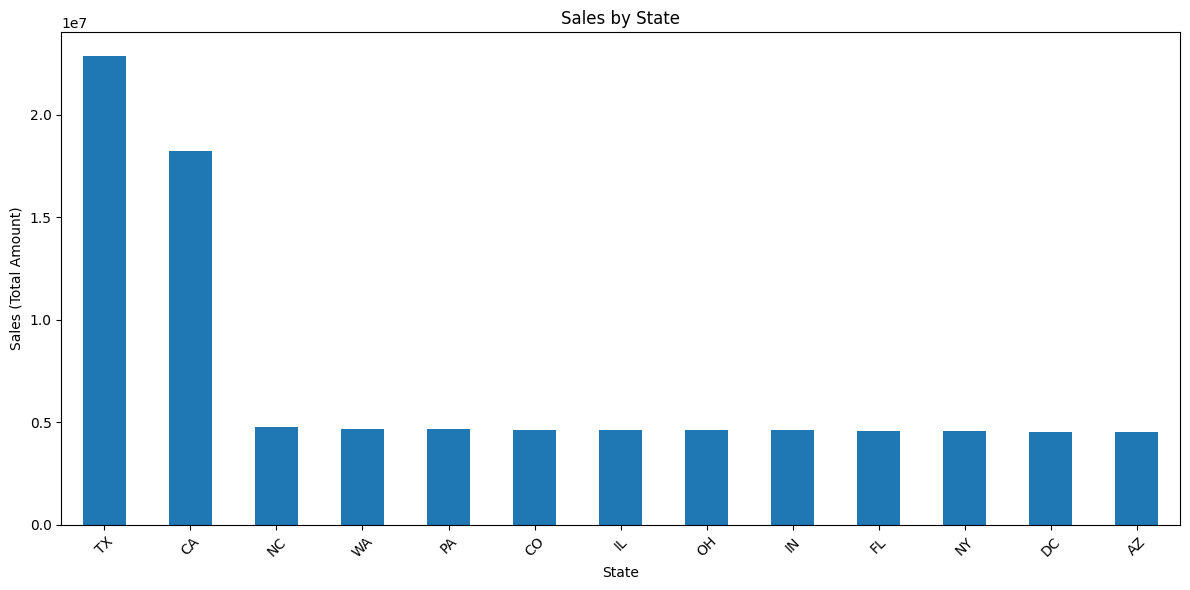

In [28]:
state_sales = (
    df.groupby("State")["TotalAmount"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))
state_sales.plot(kind="bar")

plt.title("Sales by State")
plt.xlabel("State")
plt.ylabel("Sales (Total Amount)")
plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [29]:
plt.savefig("sales_by_state.png")

<Figure size 640x480 with 0 Axes>

## Category-wise Sales (Pie Chart)

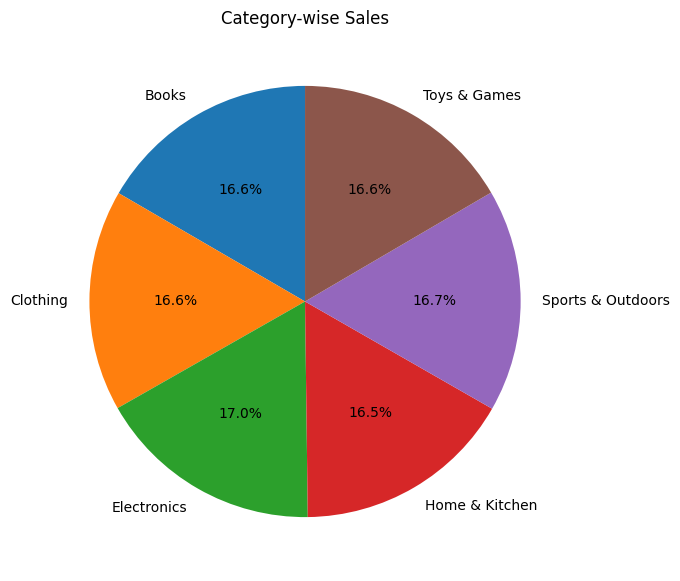

In [30]:
category_sales = (
    df.groupby("Category")["TotalAmount"]
      .sum()
)

plt.figure(figsize=(7,7))

plt.pie(
    category_sales,
    labels=category_sales.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Category-wise Sales")

plt.show()

In [31]:
plt.savefig("category_sales.png")

<Figure size 640x480 with 0 Axes>

## Monthly Sales Trend (Line Chart)

In [32]:
df["OrderDate"] = pd.to_datetime(df["OrderDate"])

df["Month-Year"] = df["OrderDate"].dt.to_period("M")

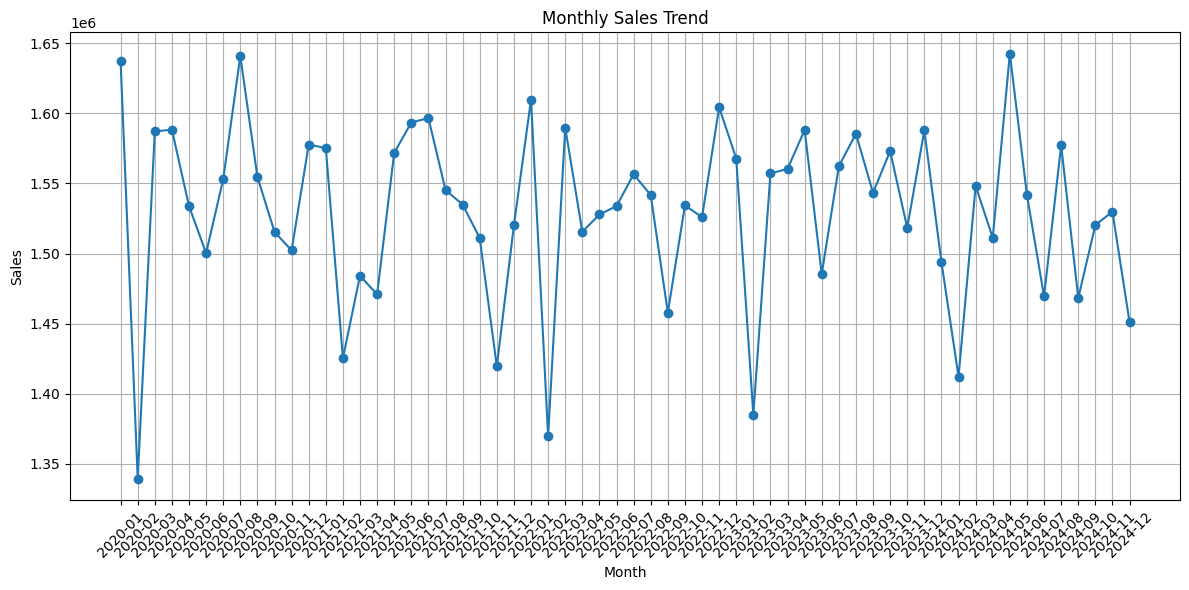

In [33]:
monthly_sales = (
    df.groupby("Month-Year")["TotalAmount"]
      .sum()
)

plt.figure(figsize=(12,6))

plt.plot(monthly_sales.index.astype(str),
         monthly_sales.values,
         marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

plt.show()

In [34]:
plt.savefig("monthly_sales.png")

<Figure size 640x480 with 0 Axes>

## Top 10 Products

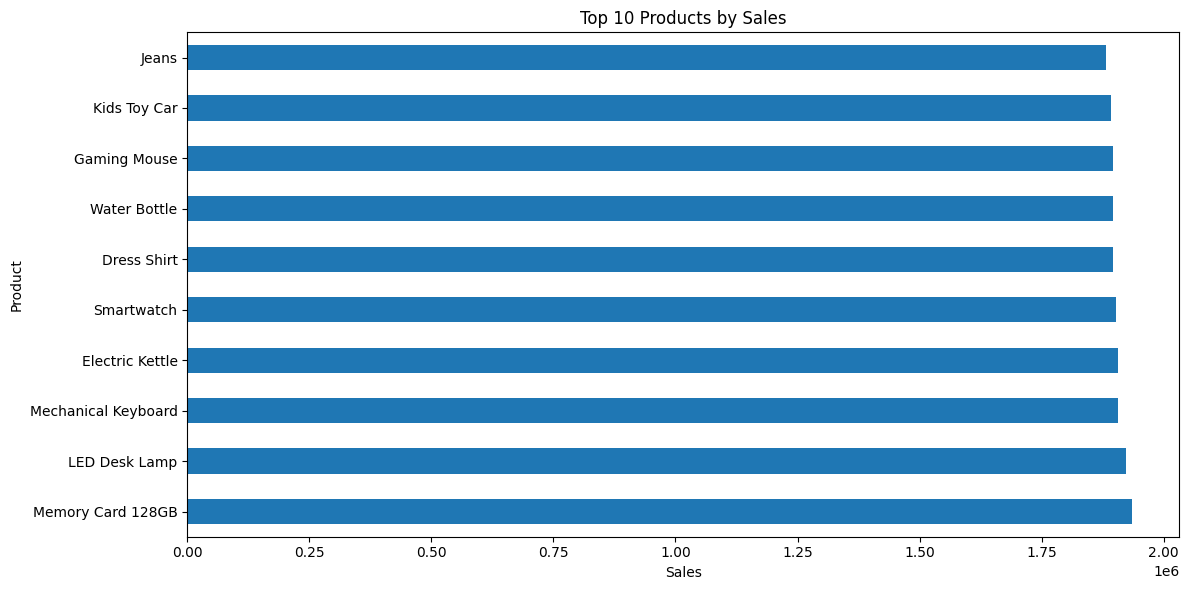

In [35]:
top_products = (
    df.groupby("ProductName")["TotalAmount"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

top_products.plot(kind="barh")

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")

plt.tight_layout()

plt.show()

In [36]:
plt.savefig("top10_products.png")

<Figure size 640x480 with 0 Axes>

## Payment Method Distribution

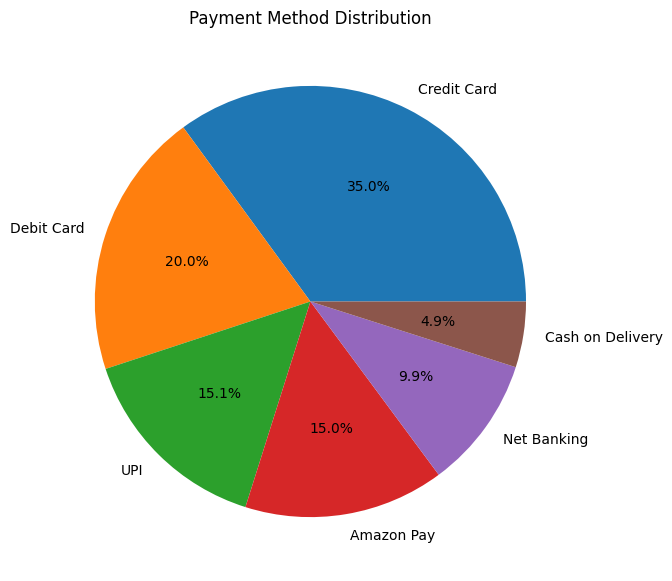

In [37]:
payment = df["PaymentMethod"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    payment,
    labels=payment.index,
    autopct="%1.1f%%"
)

plt.title("Payment Method Distribution")

plt.show()

## Top 10 Customers

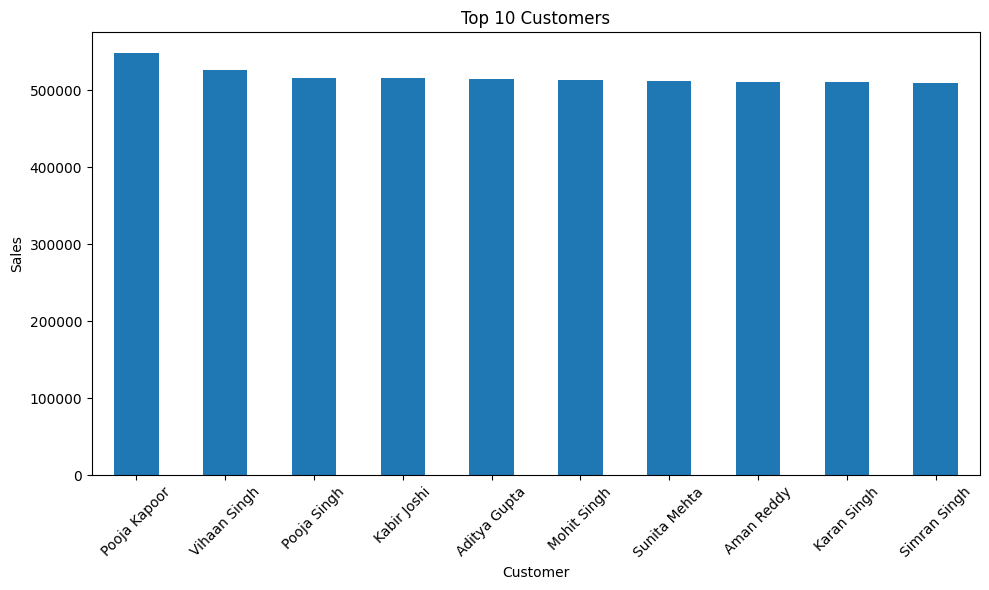

In [38]:
top_customers = (
    df.groupby("CustomerName")["TotalAmount"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

top_customers.plot(kind="bar")

plt.title("Top 10 Customers")
plt.xlabel("Customer")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## Business Insights

## Total sales
* total sales : ₹91825647.92

In [39]:
total_sales = df["TotalAmount"].sum()
print(total_sales)

91825647.92


## Sales by State
 * Highest sales State: TX
 * Lowest sales state: AZ

In [40]:
state_sales = (
    df.groupby("State")["TotalAmount"]
      .sum()
      .sort_values(ascending=False)
)

print(state_sales)

State
TX    22862540.54
CA    18231196.79
NC     4747701.73
WA     4660962.17
PA     4650673.88
CO     4638498.97
IL     4632847.44
OH     4615442.32
IN     4609048.43
FL     4597177.27
NY     4554358.08
DC     4520876.11
AZ     4504324.19
Name: TotalAmount, dtype: float64


## Sales by Category
 * Highest revenue category: Electronics
 * Lowest revenue category: Home & Kitchen

In [41]:
category_sales = df.groupby("Category")["TotalAmount"].sum()

print(category_sales)

Category
Books                15261837.01
Clothing             15253397.50
Electronics          15584217.18
Home & Kitchen       15163939.36
Sports & Outdoors    15345571.88
Toys & Games         15216684.99
Name: TotalAmount, dtype: float64


## Top Products
 * The highest-selling product is Memory Card 128GB

In [42]:
top_products

,TotalAmount
ProductName,
Memory Card 128GB,1935138.40
LED Desk Lamp,1921948.41
Mechanical Keyboard,1906963.54
Electric Kettle,1905751.79
Smartwatch,1901275.59
Dress Shirt,1896765.36
Water Bottle,1895467.95
Gaming Mouse,1895103.98
Kids Toy Car,1891082.43


## Top Customers
 * the top customer is Pooja Kapoor

In [43]:
top_customers

,TotalAmount
CustomerName,
Pooja Kapoor,547832.64
Vihaan Singh,526675.89
Pooja Singh,516451.45
Kabir Joshi,515361.68
Aditya Gupta,515005.09
Mohit Singh,513513.19
Sunita Mehta,511642.91
Aman Reddy,511236.91
Karan Singh,510900.60


## Payment Method
 * The most preferred payment method is Credit Card.

In [44]:
top_payment = df["PaymentMethod"].value_counts()

print(top_payment)

PaymentMethod
Credit Card         35038
Debit Card          20024
UPI                 15066
Amazon Pay          15017
Net Banking          9927
Cash on Delivery     4928
Name: count, dtype: int64


## Monthly Trend
 * Sales increased steadily from January to April, indicating positive business growth.

In [45]:
df["Month-Year"] = df["OrderDate"].dt.strftime("%b-%Y")

In [46]:
monthly_sales = (
    df.groupby("Month-Year")["TotalAmount"]
      .sum()
)

print(monthly_sales)

Month-Year
Apr-2020    1588347.29
Apr-2021    1470885.02
Apr-2022    1515497.24
Apr-2023    1560322.12
Apr-2024    1511151.55
Aug-2020    1640874.93
Aug-2021    1545324.30
Aug-2022    1541701.50
Aug-2023    1585424.79
Aug-2024    1577272.85
Dec-2020    1577655.06
Dec-2021    1520160.14
Dec-2022    1604276.23
Dec-2023    1587813.81
Dec-2024    1451073.77
Feb-2020    1339388.21
Feb-2021    1425365.99
Feb-2022    1369866.29
Feb-2023    1384957.09
Feb-2024    1412146.91
Jan-2020    1637069.40
Jan-2021    1575253.23
Jan-2022    1609759.87
Jan-2023    1567772.07
Jan-2024    1493946.70
Jul-2020    1552981.94
Jul-2021    1596668.40
Jul-2022    1556516.29
Jul-2023    1562298.78
Jul-2024    1469460.10
Jun-2020    1500269.29
Jun-2021    1593398.08
Jun-2022    1533829.81
Jun-2023    1485367.09
Jun-2024    1541772.48
Mar-2020    1587125.66
Mar-2021    1484165.89
Mar-2022    1589809.35
Mar-2023    1557146.56
Mar-2024    1548280.27
May-2020    1533834.17
May-2021    1571842.25
May-2022    1527845.26


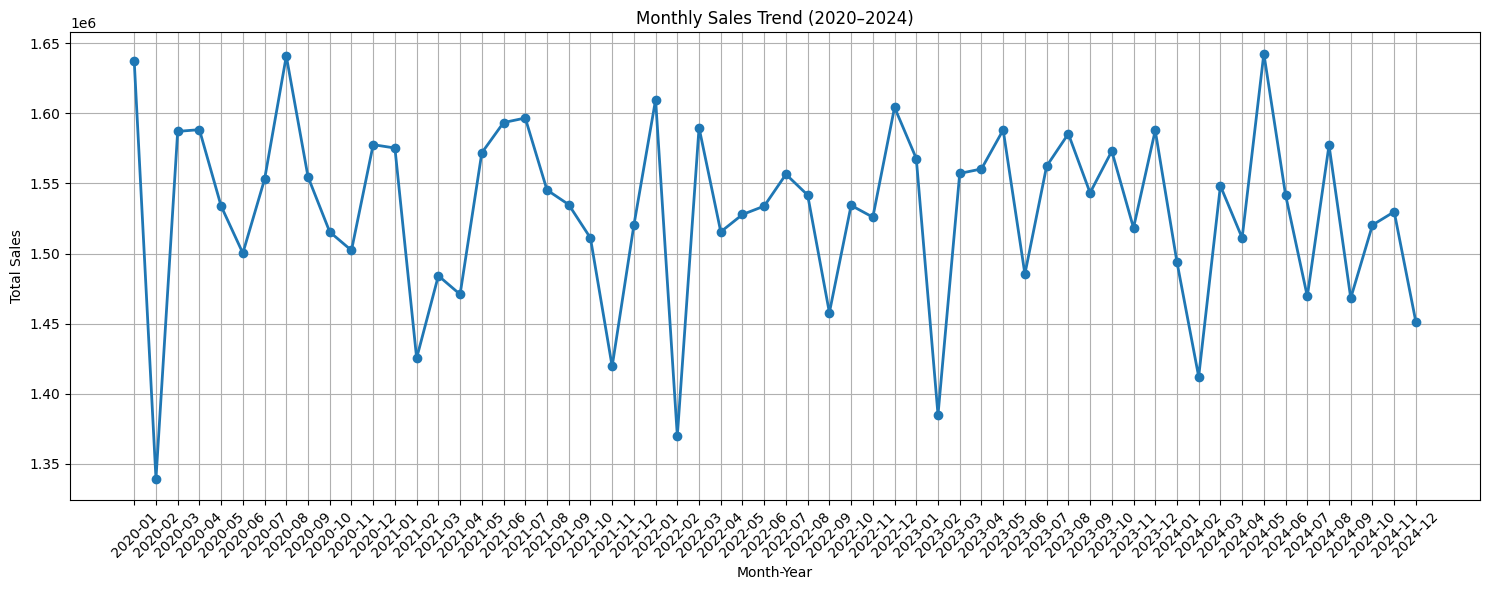

In [48]:
# Convert OrderDate to datetime
df["OrderDate"] = pd.to_datetime(df["OrderDate"])

# Create Month-Year
df["Month-Year"] = df["OrderDate"].dt.to_period("M")

# Group by Month-Year
monthly_sales = df.groupby("Month-Year")["TotalAmount"].sum()

# Plot
plt.figure(figsize=(15,6))

plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values,
    marker='o',
    linewidth=2
)

plt.title("Monthly Sales Trend (2020–2024)")
plt.xlabel("Month-Year")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

* Monthly sales remained fairly consistent between 2020 and 2024, ranging from approximately ₹1.34 million to ₹1.64 million. The highest sales occurred in May 2024, while the lowest occurred in February 2020. Overall, the sales pattern shows seasonal fluctuations rather than a continuous upward or downward trend.

# Business Insights

### 1. Overall Sales
- Total Sales: ₹91825647.92

### 2. State Performance
- Highest Sales State: Tx
- Lowest Sales State: AZ

### 3. Category Performance
- Highest Revenue Category: Electronics

### 4. Product Performance
- Top Selling Product: Memory Card 128GB

### 5. Customer Analysis
- Top Customer:  Pooja Kapoor

### 6. Payment Analysis
- Most Preferred Payment Method:Credit Card

### 7. Monthly Sales Trend
- Highest Sales Month: April-2024
- Lowest Sales Month: January-2020
- Sales remained relatively stable with seasonal fluctuations.

## **Business Recommendations**

1. Increase inventory for top-selling products to prevent stock shortages.

2. Focus marketing campaigns on low-performing states to improve sales.

3. Continue promoting the most popular payment method to enhance customer convenience.

In [49]:
df.to_csv("cleaned_amazon_sales.csv", index=False)

# Project Conclusion

* The analysis shows that Electronics is the highest revenue-generating category, while Credit Card is the most preferred payment method. Sales remained relatively stable across the five-year period with seasonal fluctuations. Texas generated the highest sales, whereas Arizona recorded the lowest. These insights can help management improve inventory planning, strengthen marketing in low-performing regions, and focus on high-demand products.